# Preamble



In [ ]:
%pip install qiskit numpy
%pip install pylatexenc
%pip install qiskit_aer
%pip install qiskit
%pip install qiskit-aer qiskit-ibm-runtime

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService

# import basic plot tools
from qiskit.visualization import plot_histogram

# Generate Diffuser

Construct the diffuser (inversion operator) $U_D$.

In [ ]:
def diffuser(nqubits):
    """
    Construct a Grover diffuser acting on nqubits search qubits, implementing inversion about the mean.
    """
    if nqubits < 1:
        raise ValueError("The diffuser needs at least one search qubit.")

    qc = QuantumCircuit(nqubits, name="U_s")
    # |s> --> |00...0>
    for qubit in range(nqubits):
        qc.h(qubit)

    # |00...0> --> |11...1>
    for qubit in range(nqubits):
        qc.x(qubit)

    # Multi-controlled Z gate
    if nqubits == 1:
        qc.z(0)

    else:
        target = nqubits - 1
        controls = list(range(nqubits - 1))
        # H - MCX - H turns a multi-controlled X into a multi-controlled Z
        qc.h(target)
        qc.mcx(controls, target)
        qc.h(target)

    # |11...1> --> |00...0>
    for qubit in range(nqubits):
        qc.x(qubit)

    # |00...0> --> |s>
    for qubit in range(nqubits):
        qc.h(qubit)

    # Return the diffuser as a reusable gate
    diffuser_gate = qc.to_gate()
    diffuser_gate.name = "U_s"

    return diffuser_gate

# Generate the Grover Oracle

We are comparing classical (computational basis) states. For convenience, we can compile this set of comparisons into a list of clauses:

In [ ]:
# ============================================================
# 1. Enter your 4x4 Sudoku
#   0 = blank
#   1, 2, 3, 4 = provided entries
# ============================================================

puzzle = [
    [1, 2, 3, 4],
    [3, 4, 0, 2],
    [2, 1, 4, 3],
    [4, 3, 2, 0],]

There are four blank cells, so only eight search qubits participate in the diffuser.

In [ ]:
from itertools import combinations

def generate_reduced_clause_list(puzzle):
    """
    Generate only the constraints involving at least one blank cell.
    Each cell i is represented by two qubits:
        [2*i, 2*i + 1]
    Each clause has the form:
        [a0, a1, b0, b1]
    """

    if len(puzzle) != 4 or any(len(row) != 4 for row in puzzle):
        raise ValueError("The puzzle must be 4x4.")
    blank_cells = {4 * row + column for row in range(4) for column in range(4) if puzzle[row][column] == 0}
    units = []

    # Constraints on rows
    for row in range(4):
        units.append([4 * row + column for column in range(4)])

    # Constraints on columns
    for column in range(4):
        units.append([4 * row + column for row in range(4)])

    # 2x2 boxes
    for box_row in (0, 2):
        for box_column in (0, 2):
            units.append([4 * row + column for row in range(box_row, box_row + 2) for column in range(box_column, box_column + 2)])

    # Generate all unique Sudoku-neighbor pairs
    all_pairs = set()
    for unit in units:
        for cell_a, cell_b in combinations(unit, 2):
            all_pairs.add(tuple(sorted((cell_a, cell_b))))

    # Keep only pairs involving at least one blank cell
    relevant_pairs = sorted((cell_a, cell_b) for cell_a, cell_b in all_pairs if cell_a in blank_cells or cell_b in blank_cells)

    # Convert cell pairs into four-qubit clauses
    clause_list = [[2 * cell_a, 2 * cell_a + 1, 2 * cell_b, 2 * cell_b + 1,] for cell_a, cell_b in relevant_pairs]
    return clause_list, relevant_pairs, blank_cells

In [ ]:
clause_list, relevant_pairs, blank_cells = (generate_reduced_clause_list(puzzle))

print("Blank cells:", sorted(blank_cells))
print("Number of clauses:", len(clause_list))

for clause in clause_list:
    print(clause)

Blank cells: [6, 15]
Number of clauses: 14
[4, 5, 12, 13]
[6, 7, 12, 13]
[6, 7, 30, 31]
[8, 9, 12, 13]
[10, 11, 12, 13]
[12, 13, 14, 15]
[12, 13, 20, 21]
[12, 13, 28, 29]
[14, 15, 30, 31]
[20, 21, 30, 31]
[22, 23, 30, 31]
[24, 25, 30, 31]
[26, 27, 30, 31]
[28, 29, 30, 31]


Construct the circuit representation of these clauses, involving two work qubits `output1` and `output2`. The `output` qubit is flipped from $|0\rangle$ to $|1\rangle$ if any of these work qubits does.

In [ ]:
def XOR(qc, a0, a1, b0, b1, output1, output2, output):
  #XOR the first bits
  qc.cx(a0, output1)
  qc.cx(b0, output1)

  #XOR the second bits
  qc.cx(a1, output2)
  qc.cx(b1, output2)

  # OR the work qubits
  qc.cx(output1, output)
  qc.cx(output2, output)
  qc.ccx(output1, output2, output)


This circuit checks whether input[0] == input[2] (and stores the output to output0) and input[1] == input[3] (and stores the output to output1). And if both those condition statisfy and these two registers are equal then stores the output to output2. To check each clause, we repeat this circuit for each pairing in clause_list and store the output to a new bit:

In [ ]:
# We will use separate registers to name the bits
in_qubits = QuantumRegister(4, name='input')
out_qubit = QuantumRegister(3, name='output')
qc = QuantumCircuit(in_qubits, out_qubit)
XOR(qc, in_qubits[0], in_qubits[1], in_qubits[2], in_qubits[3], out_qubit[0],out_qubit[1],out_qubit[2])
qc.draw()

input_0: ──■────────────────────────────────
            │                                
 input_1: ──┼────■───────────────────────────
            │    │                           
 input_2: ──┼────┼────■──────────────────────
            │    │    │                      
 input_3: ──┼────┼────┼────■─────────────────
          ┌─┴─┐  │  ┌─┴─┐  │                 
output_0: ┤ X ├──┼──┤ X ├──┼────■─────────■──
          └───┘┌─┴─┐└───┘┌─┴─┐  │         │  
output_1: ─────┤ X ├─────┤ X ├──┼────■────■──
               └───┘     └───┘┌─┴─┐┌─┴─┐┌─┴─┐
output_2: ────────────────────┤ X ├┤ X ├┤ X ├
                              └───┘└───┘└───┘

The Sudoku oracle is constructed by constructing the `XOR` circuit for all clauses.

In [ ]:
def sudoku_oracle(qc, clause_list, clause_qubits):
  # Compute clauses
  for k, clause in enumerate(clause_list):
    a0, a1, b0, b1 = clause
    XOR(qc, var_qubits[a0], var_qubits[a1], var_qubits[b0], var_qubits[b1], work_qubits[0], work_qubits[1], clause_qubits[k])

  # Flip 'output' bit if all clauses are satisfied
  qc.mcx(list(clause_qubits), output_qubit[0])

  # Uncompute clauses to reset clause-checking bits to 0
  for k in reversed(range(len(clause_list))):
    a0, a1, b0, b1 = clause_list[k]
    XOR(qc, var_qubits[a0], var_qubits[a1], var_qubits[b0], var_qubits[b1], work_qubits[0], work_qubits[1], clause_qubits[k])

Create registers.

In [ ]:
var_qubits = QuantumRegister(32, name='v')
clause_qubits = QuantumRegister(len(clause_list), name='c')
work_qubits = QuantumRegister(2, name='w')
output_qubit = QuantumRegister(1, name='out')

In [ ]:
# Identify all unknown qubits
unknown_qubits = []

for row in range(4):
    for column in range(4):
        cell = 4 * row + column
        if puzzle[row][column] == 0:
            unknown_qubits.extend([var_qubits[2 * cell], var_qubits[2 * cell + 1]])

# Now create matching classical bits
unk_cbits = ClassicalRegister(len(unknown_qubits), name='cbits')

In [ ]:
# Create circuit
qc = QuantumCircuit(var_qubits, clause_qubits, work_qubits, output_qubit, unk_cbits)

# Initialize Sudoku variables
for row in range(4):
    for column in range(4):
        cell = 4 * row + column
        value = puzzle[row][column]
        bit0 = var_qubits[2 * cell]
        bit1 = var_qubits[2 * cell + 1]

        if value == 0:
            # Blank cell → superposition
            qc.h(bit0)
            qc.h(bit1)
        else:
            # encode the given values: 1→00, 2→01, 3→10, 4→11
            encoded_value = value - 1
            if encoded_value & 1:
                qc.x(bit0)
            if encoded_value & 2:
                qc.x(bit1)

Estimate the number of iterations $n$.

In [ ]:
# Assumes that the puzzle has exactly one solution.
import math
number_of_solutions = 1
search_space_size = 2 ** 4

theta = math.asin(math.sqrt(number_of_solutions / search_space_size))

number_of_iterations = math.floor(math.pi / (4 * theta))

print("Grover iterations:", number_of_iterations)

Initialize the `output_qubit` to $|-\rangle$. Run the Grover algorithm $(U_{\text{oracle}} U_D)^n$.

In [ ]:
# Initialize 'out0' in state |->
qc.initialize([1, -1]/np.sqrt(2), output_qubit)

# Initialize qubits in state |s>
qc.h(var_qubits)
qc.barrier()  # for visual separation

## Iterations
for _ in range(number_of_iterations):
  sudoku_oracle(qc, clause_list, clause_qubits)
  qc.barrier()  # for visual separation
  qc.append(diffuser(len(unknown_qubits)), unknown_qubits) #

qc.measure(unknown_qubits, unk_cbits)
qc.draw(fold=-1)

┌───┐                    ░                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           ░                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   ░                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   ░                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import transpile

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="uRVmNideWuThEOSbXKggMulkg3GYgY1vdyhM4pywpKz2",
    overwrite=True)

# Connect to IBM Quantum
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")
print(qc.num_qubits)
print(backend.num_qubits)

qiskit_runtime_service.__init__:WARNING:2026-06-23 02:35:43,514: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 02:35:43,518: Using instance: open-instance, plan: open


49
156


In [ ]:
# Transpile for the hardware
transpiled_qc = transpile(qc, backend=backend)

# Submit job
sampler = Sampler(mode=backend)
job = sampler.run([transpiled_qc], shots=32)

print("Job ID:", job.job_id())

result = job.result()

/usr/local/lib/python3.12/dist-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1224: UserWarning: This instance has met its usage limit. Workloads will not run until time ismade available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2Ffb708c84a43b40b1a9fc3ff137e9c8c0%3Aa0e53294-eb96-4493-87de-a0a44dc9b331%3A%3A for more details.
  warnings.warn(


Job ID: d8sv23sbp3hs7383oh1g


Plot out the results. Expected `0000` to be the strongest, from the given example.

In [ ]:
pub_result = result[0]

# counts = pub_result.data.cbits.get_counts()
counts = pub_result.data.c.get_counts()

plot_histogram(counts)

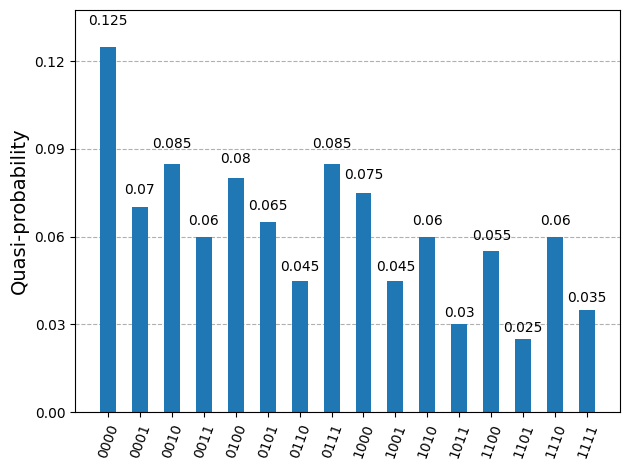

In [ ]:
from collections import Counter
from qiskit.visualization import plot_histogram

num_runs = 20
shots_per_run = 10

total_counts = Counter()

for _ in range(num_runs):
    job = sampler.run([transpiled_qc], shots=shots_per_run)
    result = job.result()

    pub_result = result[0]
    counts = pub_result.data.cbits.get_counts()

    total_counts.update(counts)

# optional: normalize to probabilities
total_shots = num_runs * shots_per_run
probabilities = {k: v / total_shots for k, v in total_counts.items()}

plot_histogram(probabilities)

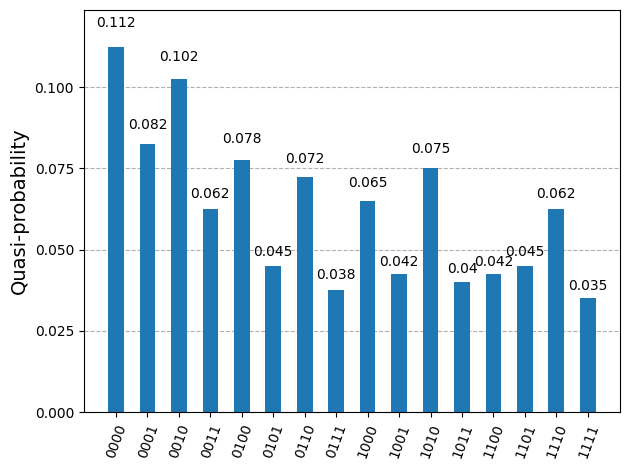

In [ ]:
from collections import Counter
from qiskit.visualization import plot_histogram

num_runs = 20
shots_per_run = 20

total_counts = Counter()

for _ in range(num_runs):
    job = sampler.run([transpiled_qc], shots=shots_per_run)
    result = job.result()

    pub_result = result[0]
    counts = pub_result.data.cbits.get_counts()

    total_counts.update(counts)

# optional: normalize to probabilities
total_shots = num_runs * shots_per_run
probabilities2 = {k: v / total_shots for k, v in total_counts.items()}

plot_histogram(probabilities2)

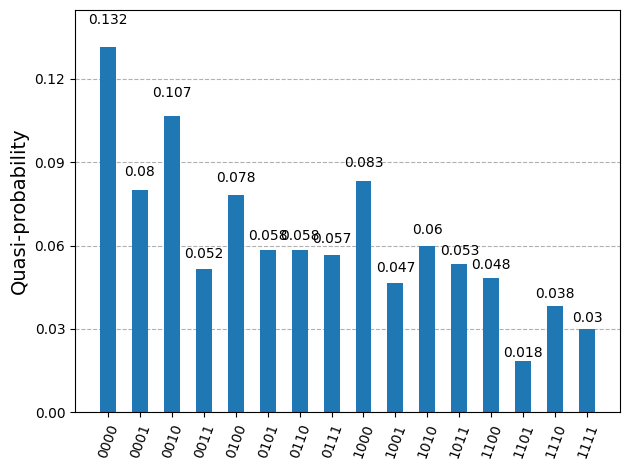

In [ ]:
from collections import Counter
from qiskit.visualization import plot_histogram

num_runs = 30
shots_per_run = 20

total_counts = Counter()

for _ in range(num_runs):
    job = sampler.run([transpiled_qc], shots=shots_per_run)
    result = job.result()

    pub_result = result[0]
    counts = pub_result.data.cbits.get_counts()

    total_counts.update(counts)

# optional: normalize to probabilities
total_shots = num_runs * shots_per_run
probabilities3 = {k: v / total_shots for k, v in total_counts.items()}

plot_histogram(probabilities3)

In [ ]:
num_runs = 40
shots_per_run = 20

total_counts = Counter()

for _ in range(num_runs):
    job = sampler.run([transpiled_qc], shots=shots_per_run)
    result = job.result()

    pub_result = result[0]
    counts = pub_result.data.cbits.get_counts()

    total_counts.update(counts)

# optional: normalize to probabilities
total_shots = num_runs * shots_per_run
probabilities4 = {k: v / total_shots for k, v in total_counts.items()}

plot_histogram(probabilities4)


/usr/local/lib/python3.12/dist-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1224: UserWarning: This instance has met its usage limit. Workloads will not run until time ismade available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2Ffb708c84a43b40b1a9fc3ff137e9c8c0%3Aa0e53294-eb96-4493-87de-a0a44dc9b331%3A%3A for more details.
  warnings.warn(
